# 第八章配套实验：随机梯度、Mini-batch、Momentum 与 AdamW

这个 Notebook 按新版课件顺序整理为“课后/课堂实验任务书”。主线是：先理解 SGD / Mini-batch 为什么能降低单步成本，再观察训练实践中的 batch size 与学习率调度，随后进入 Momentum、Nesterov、AdaGrad、RMSProp、Adam 与 AdamW。

建议运行顺序：

1. 有限和目标、GD/SGD/Mini-batch 的单步代价与梯度噪声；
2. batch size 对梯度方差、训练曲线和单位时间进展的影响；
3. 学习率调度对 SGD 稳定性的影响；
4. 应用案例小实验：推荐/embedding 风格的稀疏更新；
5. Momentum 如何平滑 mini-batch 噪声导致的 zig-zag；
6. Nesterov 与普通 Momentum 的轨迹直观比较；
7. AdaGrad 在稀疏特征和坐标尺度差异下的效果；
8. RMSProp 与 AdaGrad 长时间训练时有效步长的差异；
9. Adam 的一阶矩、二阶矩、偏差修正与坐标级有效步长；
10. AdamW/权重衰减与最后的优化器选择思考题。

课堂建议：先运行公共函数，再依次运行实验 1 到实验 10。最常修改的参数是 `batch_size`、`lr`、`epochs`、`momentum`、`beta1`、`beta2` 和 `weight_decay`。

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PICS = BASE / "pics"
PICS.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]

SHANSHU = "#841e34"
BLUE = "#46445D"
DEEP_GREEN = "#0A6B3A"
ORANGE = "#AC7088"
PURPLE = "#6750A4"
HALF_GRAY = "0.55"

rng = np.random.default_rng(42)
summaries = []


def add_summary(experiment, method, iterations, runtime, final_loss, note=""):
    summaries.append({
        "experiment": experiment,
        "method": method,
        "iterations": iterations,
        "runtime_sec": runtime,
        "final_loss": final_loss,
        "note": note,
    })


def moving_average(values, window=20):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))


def show_note(text):
    """Display a short classroom-style interpretation below each result."""
    display(Markdown(text))


def show_saved(path):
    print(f"图片已保存: {path}")


print(f"图片会保存到: {PICS}")

图片会保存到: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics


## 公共函数：有限和目标与随机优化器

为了和课件公式对应，Notebook 主要使用线性回归经验风险：

$$
f(w)=\frac1n\sum_{i=1}^n f_i(w),\qquad
f_i(w)=\frac12(x_i^T w-y_i)^2.
$$

全梯度和 mini-batch 梯度分别是

$$
\nabla f(w)=\frac1nX^T(Xw-y),\qquad
g_B(w)=\frac1{|B|}X_B^T(X_Bw-y_B).
$$

其中 $B$ 是当前 batch 的样本下标集合。

In [2]:
def make_linear_data(n=6000, d=30, noise=0.5, condition=20.0, seed=0):
    """Generate a controlled least-squares problem with anisotropic feature scales."""
    gen = np.random.default_rng(seed)
    scales = np.geomspace(condition, 1.0, d)
    X = gen.normal(size=(n, d)) / np.sqrt(scales)
    w_true = gen.normal(size=d)
    y = X @ w_true + noise * gen.normal(size=n)
    return X, y, w_true


def mse_loss(X, y, w):
    r = X @ w - y
    return 0.5 * np.mean(r * r)


def full_grad(X, y, w):
    return X.T @ (X @ w - y) / len(y)


def batch_grad(X, y, w, idx):
    Xb = X[idx]
    yb = y[idx]
    return Xb.T @ (Xb @ w - yb) / len(idx)


def lipschitz_constant(X):
    return np.linalg.eigvalsh(X.T @ X / len(X)).max()


def iterate_minibatches(n, batch_size, gen, shuffle=True):
    if batch_size >= n:
        yield np.arange(n)
        return
    order = gen.permutation(n) if shuffle else np.arange(n)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


def lr_schedule(kind, step, total_steps, base_lr, warmup_steps=0):
    if warmup_steps > 0 and step < warmup_steps:
        return base_lr * (step + 1) / warmup_steps
    if kind == "constant":
        return base_lr
    if kind == "sqrt_decay":
        return base_lr / np.sqrt(step + 1)
    if kind == "step_decay":
        return base_lr * (0.2 ** (step // max(total_steps // 3, 1)))
    if kind == "cosine":
        progress = step / max(total_steps - 1, 1)
        return 0.05 * base_lr + 0.95 * base_lr * 0.5 * (1 + np.cos(np.pi * progress))
    raise ValueError(f"unknown schedule: {kind}")


def train_least_squares(
    X,
    y,
    method="sgd",
    batch_size=64,
    epochs=20,
    lr=0.1,
    schedule="constant",
    momentum=0.0,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    weight_decay=0.0,
    decoupled_weight_decay=False,
    seed=0,
    w0=None,
    record_every=1,
):
    gen = np.random.default_rng(seed)
    n, d = X.shape
    w = np.zeros(d) if w0 is None else w0.astype(float).copy()
    velocity = np.zeros(d)
    second = np.zeros(d)
    first = np.zeros(d)
    steps_per_epoch = int(np.ceil(n / batch_size))
    total_steps = epochs * steps_per_epoch
    losses, grad_norms, lr_hist, w_hist = [], [], [], []

    step = 0
    start = perf_counter()
    for _ in range(epochs):
        for idx in iterate_minibatches(n, batch_size, gen):
            if schedule == "cosine_warmup":
                alpha = lr_schedule("cosine", step, total_steps, lr, warmup_steps=max(5, total_steps // 20))
            else:
                alpha = lr_schedule(schedule, step, total_steps, lr)

            g = batch_grad(X, y, w, idx)
            if weight_decay > 0 and not decoupled_weight_decay:
                g = g + weight_decay * w

            if method == "sgd":
                w = w - alpha * g
            elif method == "momentum":
                velocity = momentum * velocity + g
                w = w - alpha * velocity
            elif method == "adagrad":
                second = second + g * g
                w = w - alpha * g / (np.sqrt(second) + eps)
            elif method == "rmsprop":
                second = beta2 * second + (1 - beta2) * (g * g)
                w = w - alpha * g / (np.sqrt(second) + eps)
            elif method == "adam":
                first = beta1 * first + (1 - beta1) * g
                second = beta2 * second + (1 - beta2) * (g * g)
                m_hat = first / (1 - beta1 ** (step + 1))
                v_hat = second / (1 - beta2 ** (step + 1))
                w = w - alpha * m_hat / (np.sqrt(v_hat) + eps)
            else:
                raise ValueError(f"unknown method: {method}")

            if weight_decay > 0 and decoupled_weight_decay:
                w = w - alpha * weight_decay * w

            if step % record_every == 0 or step == total_steps - 1:
                losses.append(mse_loss(X, y, w))
                grad_norms.append(np.linalg.norm(full_grad(X, y, w)))
                lr_hist.append(alpha)
                w_hist.append(w.copy())
            step += 1

    runtime = perf_counter() - start
    return {
        "w": w,
        "losses": np.array(losses),
        "grad_norms": np.array(grad_norms),
        "lr": np.array(lr_hist),
        "path": np.array(w_hist),
        "iterations": step,
        "runtime": runtime,
        "final_loss": mse_loss(X, y, w),
    }

## 实验 1：有限和目标中的单步代价与梯度噪声

对应课件“有限和目标、GD 与 SGD、Mini-batch 更新”。大规模学习常写成

$$
f(w)=\frac1n\sum_{i=1}^n f_i(w).
$$

GD 每步使用全部 $n$ 个样本，方向准确但单步代价高；SGD 每步只用 1 个样本，代价低但噪声大；Mini-batch 介于二者之间。若均匀抽样，则

$$
\mathbb{E}_{i_k}[\nabla f_{i_k}(w)]=\nabla f(w),\qquad
\mathbb{E}_{B_k}[g_{B_k}(w)]=\nabla f(w).
$$

任务：在固定点 $w$ 处反复抽样，比较不同 batch size 的梯度误差、相对单步样本量和一次梯度计算耗时。

,method,batch_size,relative_samples_per_step,avg_time_per_grad_ms,||E_hat[g_B]-grad f||,mean ||g_B-grad f||,std ||g_B-grad f||
0,SGD,1,0.000125,0.058321,2.951298e-01,6.382082e+00,4.896456e+00
1,Mini-batch,4,0.000500,0.066541,1.085077e-01,3.613260e+00,1.528373e+00
2,Mini-batch,16,0.002000,0.054844,5.751969e-02,1.913886e+00,5.227967e-01
3,Mini-batch,64,0.008000,0.068653,2.395468e-02,9.601099e-01,2.194665e-01
4,Mini-batch,256,0.032000,0.111315,1.319208e-02,4.821626e-01,1.117313e-01
5,Mini-batch,1024,0.128000,0.179132,6.093855e-03,2.270855e-01,4.962446e-02
6,GD/full batch,8000,1.000000,1.373614,2.727159e-14,2.721877e-15,8.974722e-16


**观察：** SGD 的单步样本量最低但噪声最大；batch size 增大后，梯度更接近全梯度，但一次更新要处理更多样本。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_minibatch_gradient_variance.png


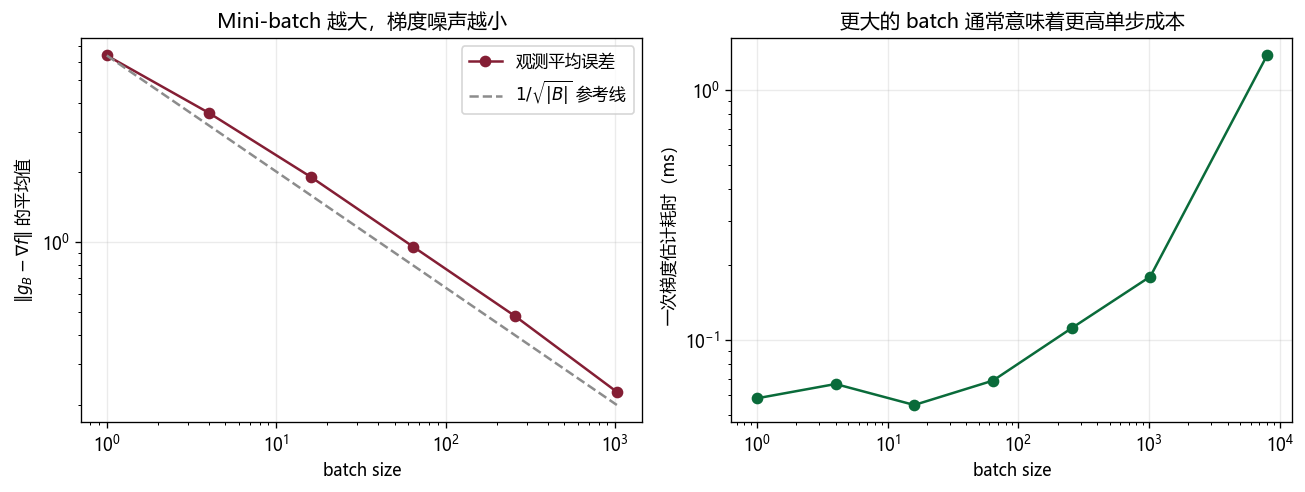

In [3]:
X, y, w_true = make_linear_data(n=8000, d=20, noise=0.8, condition=30, seed=1)
w_probe = rng.normal(size=X.shape[1])
g_full = full_grad(X, y, w_probe)

batch_sizes = [1, 4, 16, 64, 256, 1024, len(y)]
trials = 900
rows = []
gradient_errors = {}

for b in batch_sizes:
    start = perf_counter()
    grads = np.vstack([
        batch_grad(X, y, w_probe, rng.choice(len(y), size=b, replace=False))
        for _ in range(trials)
    ])
    elapsed = perf_counter() - start
    mean_grad = grads.mean(axis=0)
    errors = np.linalg.norm(grads - g_full, axis=1)
    gradient_errors[b] = errors
    rows.append({
        "method": "GD/full batch" if b == len(y) else ("SGD" if b == 1 else "Mini-batch"),
        "batch_size": b,
        "relative_samples_per_step": b / len(y),
        "avg_time_per_grad_ms": 1000 * elapsed / trials,
        "||E_hat[g_B]-grad f||": np.linalg.norm(mean_grad - g_full),
        "mean ||g_B-grad f||": errors.mean(),
        "std ||g_B-grad f||": errors.std(),
    })

unbiased_df = pd.DataFrame(rows)
display(unbiased_df)
show_note("**观察：** SGD 的单步样本量最低但噪声最大；batch size 增大后，梯度更接近全梯度，但一次更新要处理更多样本。")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_df = unbiased_df[unbiased_df["batch_size"] < len(y)]
axes[0].loglog(plot_df["batch_size"], plot_df["mean ||g_B-grad f||"], marker="o", color=SHANSHU, label="观测平均误差")
reference = plot_df["mean ||g_B-grad f||"].iloc[0] / np.sqrt(plot_df["batch_size"])
axes[0].loglog(plot_df["batch_size"], reference, "--", color=HALF_GRAY, label=r"$1/\sqrt{|B|}$ 参考线")
axes[0].set_xlabel("batch size")
axes[0].set_ylabel(r"$\|g_B-\nabla f\|$ 的平均值")
axes[0].set_title("Mini-batch 越大，梯度噪声越小")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].loglog(unbiased_df["batch_size"], unbiased_df["avg_time_per_grad_ms"], marker="o", color=DEEP_GREEN)
axes[1].set_xlabel("batch size")
axes[1].set_ylabel("一次梯度估计耗时（ms）")
axes[1].set_title("更大的 batch 通常意味着更高单步成本")
axes[1].grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(PICS / "sgd_minibatch_gradient_variance.png")
show_saved(PICS / "sgd_minibatch_gradient_variance.png")
plt.show()

add_summary("实验1", "GD/SGD/Mini-batch", trials, float(unbiased_df["avg_time_per_grad_ms"].sum() / 1000), unbiased_df["mean ||g_B-grad f||"].iloc[-1], "单步代价与梯度噪声比较")

## 实验 2：Batch size 对训练曲线与单位时间进展的影响

对应课件“Iteration、Batch、Epoch”和“Batch size 如何影响训练”。若训练集大小为 $n$，batch size 为 $b$，则一个 epoch 大约有 $\lceil n/b\rceil$ 次 iteration。

本实验把原来的“GD/SGD/Mini-batch 曲线”和“batch、epoch、iteration 关系”合并：同时比较梯度噪声、loss 曲线、每秒进展和每个 epoch 的更新次数。任务是回答：batch 越大是否一定越快、越稳、越好？

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_batch_size_loss_time_tradeoff.png


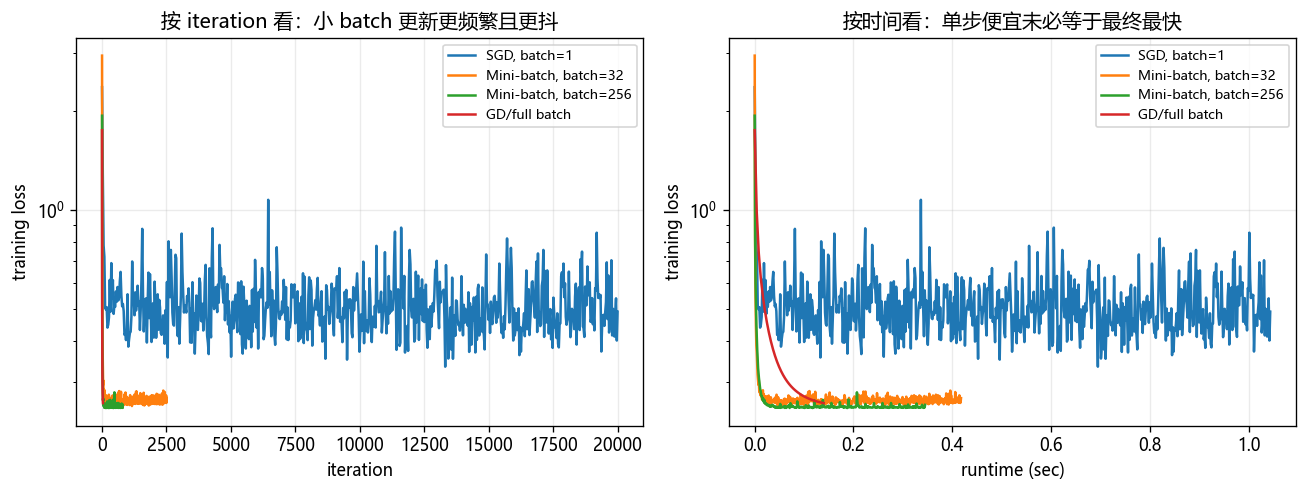

,method,batch_size,iterations_per_epoch,iterations,runtime_sec,loss_drop_per_sec,loss_std_last_30,final_loss
2,"Mini-batch, batch=256",256,40,800,0.344979,4.862212,0.001678,0.254893
3,GD/full batch,10000,1,35,0.139647,10.655090,0.061547,0.257957
1,"Mini-batch, batch=32",32,313,2504,0.417725,6.407983,0.006642,0.267211
0,"SGD, batch=1",1,10000,20000,1.043755,1.791581,0.100098,0.489592


**观察：** 小 batch 每个 epoch 更新次数多、曲线更抖；大 batch 梯度更稳但单步成本更高。实际训练常比较单位时间进展，而不只比较 iteration 数。

In [4]:
X2, y2, _ = make_linear_data(n=10000, d=30, noise=0.7, condition=25, seed=2)
L = lipschitz_constant(X2)
base_lr = 0.7 / L
configs = [
    ("SGD, batch=1", 1, 2, base_lr * 0.15, 30),
    ("Mini-batch, batch=32", 32, 8, base_lr * 0.5, 5),
    ("Mini-batch, batch=256", 256, 20, base_lr * 0.8, 2),
    ("GD/full batch", len(y2), 35, base_lr, 1),
]

batch_results = {}
for name, batch_size, epochs, lr, record_every in configs:
    res = train_least_squares(X2, y2, method="sgd", batch_size=batch_size, epochs=epochs, lr=lr, seed=3, record_every=record_every)
    batch_results[name] = res
    add_summary("实验2", name, res["iterations"], res["runtime"], res["final_loss"], f"batch={batch_size}, lr={lr:.3g}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, res in batch_results.items():
    xs_iter = np.linspace(0, res["iterations"], len(res["losses"]))
    xs_time = np.linspace(0, res["runtime"], len(res["losses"]))
    axes[0].plot(xs_iter, res["losses"], label=name)
    axes[1].plot(xs_time, res["losses"], label=name)
for ax in axes:
    ax.set_yscale("log")
    ax.set_ylabel("training loss")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_xlabel("iteration")
axes[0].set_title("按 iteration 看：小 batch 更新更频繁且更抖")
axes[1].set_xlabel("runtime (sec)")
axes[1].set_title("按时间看：单步便宜未必等于最终最快")
fig.tight_layout()
fig.savefig(PICS / "sgd_batch_size_loss_time_tradeoff.png")
show_saved(PICS / "sgd_batch_size_loss_time_tradeoff.png")
plt.show()

batch_compare_df = pd.DataFrame([
    {
        "method": name,
        "batch_size": batch_size,
        "iterations_per_epoch": int(np.ceil(len(y2) / batch_size)),
        "iterations": res["iterations"],
        "runtime_sec": res["runtime"],
        "loss_drop_per_sec": (res["losses"][0] - res["final_loss"]) / max(res["runtime"], 1e-12),
        "loss_std_last_30": np.std(res["losses"][-30:]) if len(res["losses"]) >= 30 else np.std(res["losses"]),
        "final_loss": res["final_loss"],
    }
    for (name, batch_size, _, _, _), res in zip(configs, batch_results.values())
]).sort_values("final_loss")
display(batch_compare_df)
show_note("**观察：** 小 batch 每个 epoch 更新次数多、曲线更抖；大 batch 梯度更稳但单步成本更高。实际训练常比较单位时间进展，而不只比较 iteration 数。")

## 实验 3：学习率调度对 SGD 稳定性的影响

对应课件“学习率 $\alpha_k$：为什么 SGD 特别依赖它”和“学习率调度”。SGD 使用有噪声的方向，学习率过大容易在好区域附近持续震荡，过小又会进展缓慢。

任务：比较固定学习率、平方根衰减、分段衰减和 warmup + cosine decay。观察前期下降速度、后期抖动幅度和最终 loss。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_learning_rate_schedules.png


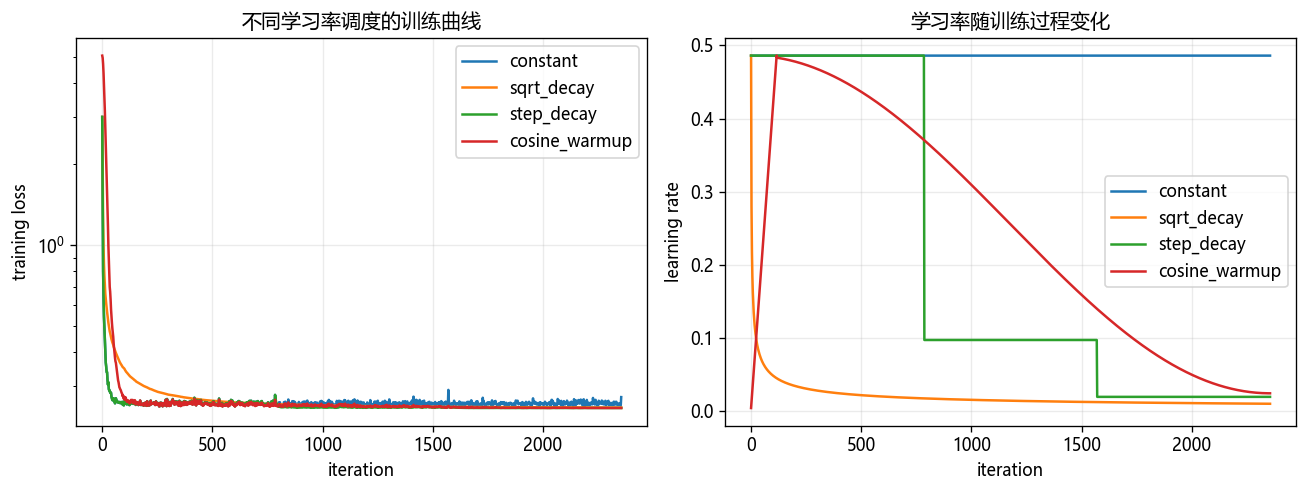

,schedule,final_loss,final_lr,late_loss_std
2,step_decay,0.248468,0.019443,0.000034
3,cosine_warmup,0.248517,0.024303,0.000053
1,sqrt_decay,0.249425,0.010016,0.000043
0,constant,0.272783,0.486064,0.003520


**观察：** 固定学习率方便但后期可能抖动；衰减和 cosine 调度能在后期减小步长，使随机更新更稳定。

In [5]:
schedules = ["constant", "sqrt_decay", "step_decay", "cosine_warmup"]
schedule_results = {}
for sched in schedules:
    res = train_least_squares(
        X2, y2, method="sgd", batch_size=64, epochs=15,
        lr=base_lr * 0.7, schedule=sched, seed=5, record_every=2
    )
    schedule_results[sched] = res
    add_summary("实验3", sched, res["iterations"], res["runtime"], res["final_loss"], "学习率调度")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for sched, res in schedule_results.items():
    xs = np.linspace(0, res["iterations"], len(res["losses"]))
    axes[0].plot(xs, res["losses"], label=sched)
    axes[1].plot(xs, res["lr"], label=sched)
axes[0].set_yscale("log")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("training loss")
axes[0].set_title("不同学习率调度的训练曲线")
axes[0].grid(True, alpha=0.25)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("learning rate")
axes[1].set_title("学习率随训练过程变化")
axes[1].grid(True, alpha=0.25)
axes[0].legend()
axes[1].legend()
fig.tight_layout()
fig.savefig(PICS / "sgd_learning_rate_schedules.png")
show_saved(PICS / "sgd_learning_rate_schedules.png")
plt.show()

schedule_df = pd.DataFrame([
    {
        "schedule": sched,
        "final_loss": res["final_loss"],
        "final_lr": res["lr"][-1],
        "late_loss_std": np.std(res["losses"][-40:]),
    }
    for sched, res in schedule_results.items()
]).sort_values("final_loss")
display(schedule_df)
show_note("**观察：** 固定学习率方便但后期可能抖动；衰减和 cosine 调度能在后期减小步长，使随机更新更稳定。")

## 实验 4：应用案例小任务：稀疏推荐与 embedding 更新

对应课件中的推荐系统、广告、LLM embedding 等案例。很多模型参数不是每个 batch 都会被更新：热门用户/商品/词经常出现，长尾 ID 很少出现。

任务：构造一个简化的“用户-物品点击预测”数据集，观察 mini-batch 训练时不同 ID 的更新频率。这个实验不追求真实推荐系统效果，只帮助理解为什么大规模稀疏参数几乎离不开随机/小批量训练，以及为什么后面 AdaGrad/Adam 会特别关注坐标级步长。

,group,mean_occurrences,mean_update_steps
0,热门用户 top10,53.1,212.4
1,长尾用户 bottom10,0.7,2.8
2,热门物品 top10,37.8,151.2
3,长尾物品 bottom10,0.0,0.0


图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_sparse_recommendation_updates.png


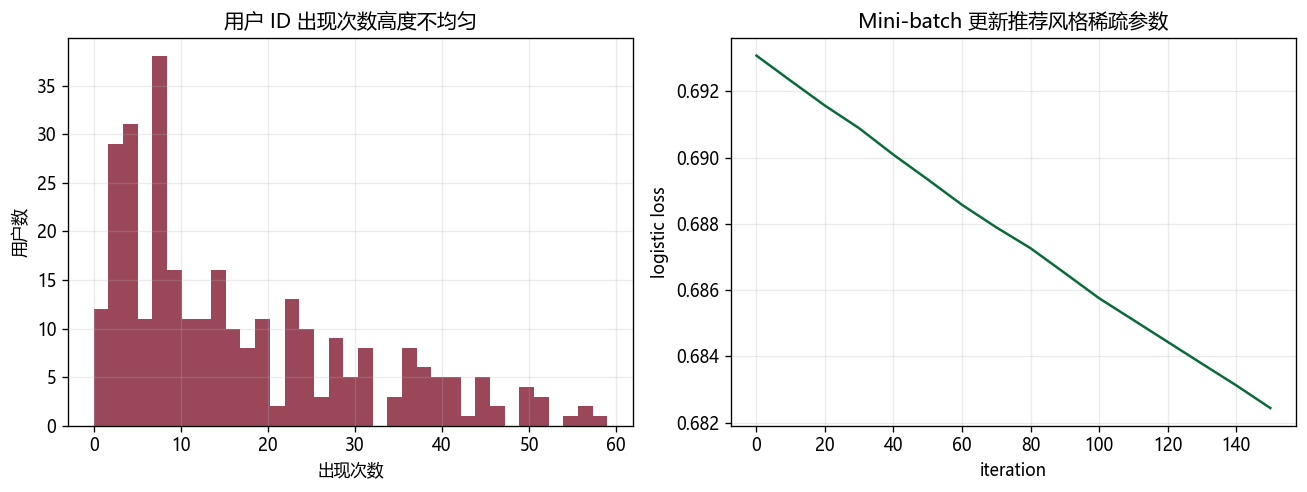

**观察：** 热门 ID 在很多 batch 中被更新，长尾 ID 更新很少。后面的 AdaGrad/Adam 会用坐标级状态处理这种更新频率差异。

In [6]:
def make_recommendation_events(n=5000, n_users=300, n_items=500, seed=21):
    gen = np.random.default_rng(seed)
    user_pop = np.geomspace(1.0, 0.05, n_users)
    item_pop = np.geomspace(1.0, 0.03, n_items)
    user_pop /= user_pop.sum()
    item_pop /= item_pop.sum()
    users = gen.choice(n_users, size=n, p=user_pop)
    items = gen.choice(n_items, size=n, p=item_pop)
    true_user = gen.normal(0, 0.8, n_users)
    true_item = gen.normal(0, 0.8, n_items)
    logits = true_user[users] + true_item[items] + 0.2 * gen.normal(size=n)
    clicks = gen.binomial(1, sigmoid(logits))
    return users, items, clicks


def train_bias_recommender(users, items, clicks, batch_size=128, epochs=4, lr=0.25, seed=22):
    gen = np.random.default_rng(seed)
    n_users = users.max() + 1
    n_items = items.max() + 1
    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_items)
    user_updates = np.zeros(n_users, dtype=int)
    item_updates = np.zeros(n_items, dtype=int)
    losses = []
    step = 0
    start = perf_counter()
    for _ in range(epochs):
        for idx in iterate_minibatches(len(clicks), batch_size, gen):
            u = users[idx]
            it = items[idx]
            yb = clicks[idx]
            pred = sigmoid(user_bias[u] + item_bias[it])
            err = pred - yb
            np.add.at(user_bias, u, -lr * err / len(idx))
            np.add.at(item_bias, it, -lr * err / len(idx))
            np.add.at(user_updates, u, 1)
            np.add.at(item_updates, it, 1)
            if step % 10 == 0:
                p_all = sigmoid(user_bias[users] + item_bias[items])
                losses.append(-np.mean(clicks * np.log(p_all + 1e-12) + (1 - clicks) * np.log(1 - p_all + 1e-12)))
            step += 1
    return {
        "losses": np.array(losses),
        "user_updates": user_updates,
        "item_updates": item_updates,
        "iterations": step,
        "runtime": perf_counter() - start,
        "final_loss": losses[-1],
    }


users, items, clicks = make_recommendation_events()
rec_res = train_bias_recommender(users, items, clicks)
user_freq = np.bincount(users, minlength=rec_res["user_updates"].size)
item_freq = np.bincount(items, minlength=rec_res["item_updates"].size)

freq_df = pd.DataFrame({
    "group": ["热门用户 top10", "长尾用户 bottom10", "热门物品 top10", "长尾物品 bottom10"],
    "mean_occurrences": [
        np.sort(user_freq)[-10:].mean(), np.sort(user_freq)[:10].mean(),
        np.sort(item_freq)[-10:].mean(), np.sort(item_freq)[:10].mean(),
    ],
    "mean_update_steps": [
        np.sort(rec_res["user_updates"])[-10:].mean(), np.sort(rec_res["user_updates"])[:10].mean(),
        np.sort(rec_res["item_updates"])[-10:].mean(), np.sort(rec_res["item_updates"])[:10].mean(),
    ],
})
display(freq_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(user_freq, bins=35, color=SHANSHU, alpha=0.82)
axes[0].set_title("用户 ID 出现次数高度不均匀")
axes[0].set_xlabel("出现次数")
axes[0].set_ylabel("用户数")
axes[0].grid(True, alpha=0.25)
axes[1].plot(np.arange(len(rec_res["losses"])) * 10, rec_res["losses"], color=DEEP_GREEN)
axes[1].set_title("Mini-batch 更新推荐风格稀疏参数")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("logistic loss")
axes[1].grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(PICS / "sgd_sparse_recommendation_updates.png")
show_saved(PICS / "sgd_sparse_recommendation_updates.png")
plt.show()

show_note("**观察：** 热门 ID 在很多 batch 中被更新，长尾 ID 更新很少。后面的 AdaGrad/Adam 会用坐标级状态处理这种更新频率差异。")
add_summary("实验4", "sparse recommendation updates", rec_res["iterations"], rec_res["runtime"], rec_res["final_loss"], "应用案例：稀疏参数与 mini-batch")

## 实验 5：Mini-batch 噪声导致 zig-zag，Momentum 如何平滑

对应课件“SGD 之后的拓展方法”“从平均噪声到平滑方向”和“案例：小批量训练中的 zig-zag”。Momentum 维护速度变量

$$
v^{k+1}=\beta v^k+(1-\beta)g_k,\qquad
w^{k+1}=w^k-\alpha v^{k+1}.
$$

这里采用指数平均写法；若使用课件中的 $v^{k+1}=\beta v^k+g_k$，可以把常数因子吸收到学习率里理解。任务：观察随机梯度在某个坐标上来回变号时，Momentum 如何保留稳定趋势并削弱摆动。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_momentum_zigzag_path.png


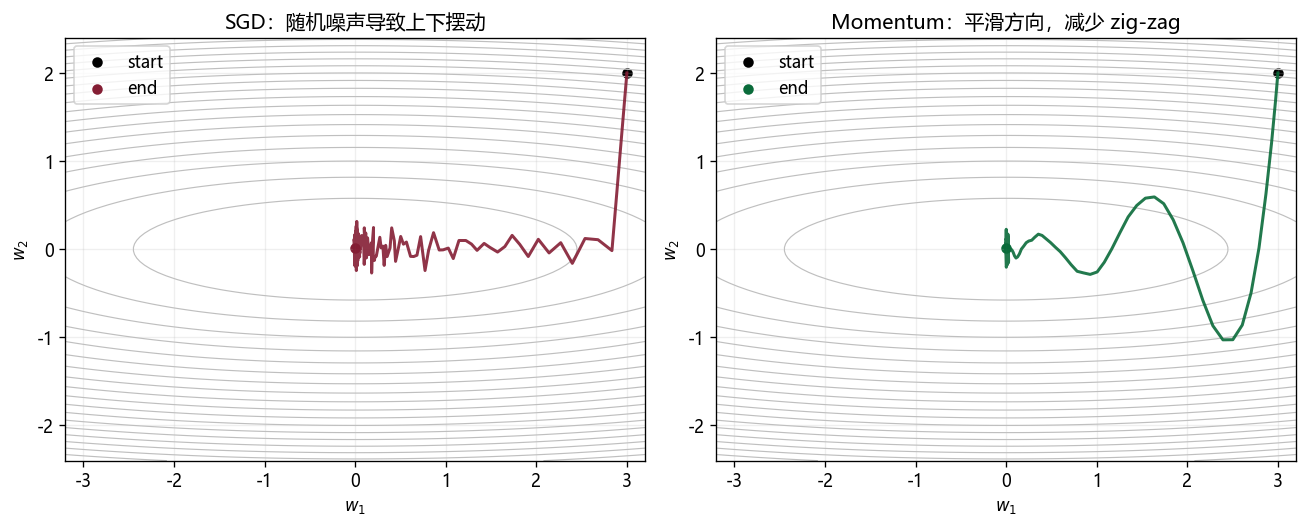

,method,final_distance,mean_abs_y_step
0,SGD,0.012230,0.136686
1,Momentum,0.010675,0.056433


**观察：** Momentum 的平均纵向摆动通常更小，说明历史梯度平滑可以抵消随机噪声方向，保留持续下降趋势。

In [7]:
def noisy_quadratic_grad(w, gen, noise_y=2.2):
    Q = np.array([[1.0, 0.0], [0.0, 18.0]])
    noise = np.array([0.15 * gen.normal(), noise_y * gen.normal()])
    return Q @ w + noise


def run_noisy_quadratic(method="sgd", steps=180, lr=0.055, beta=0.85, seed=0):
    gen = np.random.default_rng(seed)
    w = np.array([3.0, 2.0], dtype=float)
    v = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        g = noisy_quadratic_grad(w, gen)
        if method == "momentum":
            v = beta * v + (1 - beta) * g
            w = w - lr * v
        else:
            w = w - lr * g
        path.append(w.copy())
    return np.array(path)


path_sgd = run_noisy_quadratic("sgd", seed=7)
path_mom = run_noisy_quadratic("momentum", seed=7)

x1 = np.linspace(-3.2, 3.2, 120)
x2_grid = np.linspace(-2.4, 2.4, 120)
Xg, Yg = np.meshgrid(x1, x2_grid)
Z = 0.5 * Xg**2 + 9.0 * Yg**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, path, title, color in [
    (axes[0], path_sgd, "SGD：随机噪声导致上下摆动", SHANSHU),
    (axes[1], path_mom, "Momentum：平滑方向，减少 zig-zag", DEEP_GREEN),
]:
    ax.contour(Xg, Yg, Z, levels=18, colors="0.75", linewidths=0.7)
    ax.plot(path[:, 0], path[:, 1], color=color, lw=1.8, alpha=0.9)
    ax.scatter(path[0, 0], path[0, 1], color="black", s=28, label="start")
    ax.scatter(path[-1, 0], path[-1, 1], color=color, s=28, label="end")
    ax.set_xlabel(r"$w_1$")
    ax.set_ylabel(r"$w_2$")
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend()
fig.tight_layout()
fig.savefig(PICS / "sgd_momentum_zigzag_path.png")
show_saved(PICS / "sgd_momentum_zigzag_path.png")
plt.show()

zigzag_rows = pd.DataFrame({
    "method": ["SGD", "Momentum"],
    "final_distance": [np.linalg.norm(path_sgd[-1]), np.linalg.norm(path_mom[-1])],
    "mean_abs_y_step": [np.mean(np.abs(np.diff(path_sgd[:, 1]))), np.mean(np.abs(np.diff(path_mom[:, 1])))]
})
display(zigzag_rows)
show_note("**观察：** Momentum 的平均纵向摆动通常更小，说明历史梯度平滑可以抵消随机噪声方向，保留持续下降趋势。")
add_summary("实验5", "SGD vs Momentum", len(path_sgd) - 1, 0.0, zigzag_rows["final_distance"].min(), "随机二次函数轨迹")

## 实验 6：Nesterov 与普通 Momentum 的直观比较

对应课件“Nesterov 动量：先看前方再修正”。普通 Momentum 在当前位置看梯度；Nesterov 先按惯性看一眼前方，再在那里计算梯度：

$$
v^{k+1}=\beta v^k+\nabla f(w^k-\alpha\beta v^k),\qquad
w^{k+1}=w^k-\alpha v^{k+1}.
$$

任务：在同一个二次函数上比较 Momentum 与 Nesterov 的轨迹，观察“提前纠偏”如何减少冲过头。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_nesterov_vs_momentum_path.png


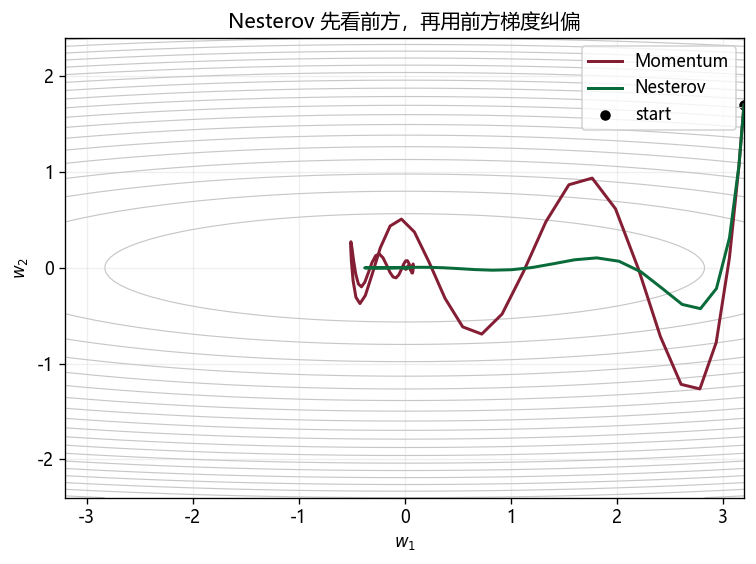

,method,final_distance,max_abs_y
0,Momentum,0.009531,1.7
1,Nesterov,0.000052,1.7


**观察：** Nesterov 在计算梯度前先移动到 lookahead 点，因此当惯性可能冲过头时，会更早感知前方坡度并修正方向。

In [8]:
def deterministic_quadratic_grad(w):
    Q = np.array([[1.0, 0.0], [0.0, 25.0]])
    return Q @ w


def run_momentum_variant(method="momentum", steps=80, lr=0.015, beta=0.88):
    w = np.array([3.2, 1.7], dtype=float)
    v = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        if method == "nesterov":
            lookahead = w - lr * beta * v
            g = deterministic_quadratic_grad(lookahead)
        else:
            g = deterministic_quadratic_grad(w)
        v = beta * v + g
        w = w - lr * v
        path.append(w.copy())
    return np.array(path)


path_momentum = run_momentum_variant("momentum")
path_nesterov = run_momentum_variant("nesterov")
Z2 = 0.5 * Xg**2 + 12.5 * Yg**2

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.contour(Xg, Yg, Z2, levels=20, colors="0.78", linewidths=0.7)
ax.plot(path_momentum[:, 0], path_momentum[:, 1], color=SHANSHU, lw=1.8, label="Momentum")
ax.plot(path_nesterov[:, 0], path_nesterov[:, 1], color=DEEP_GREEN, lw=1.8, label="Nesterov")
ax.scatter([path_momentum[0, 0]], [path_momentum[0, 1]], color="black", s=28, label="start")
ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_title("Nesterov 先看前方，再用前方梯度纠偏")
ax.grid(True, alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(PICS / "sgd_nesterov_vs_momentum_path.png")
show_saved(PICS / "sgd_nesterov_vs_momentum_path.png")
plt.show()

nesterov_df = pd.DataFrame({
    "method": ["Momentum", "Nesterov"],
    "final_distance": [np.linalg.norm(path_momentum[-1]), np.linalg.norm(path_nesterov[-1])],
    "max_abs_y": [np.max(np.abs(path_momentum[:, 1])), np.max(np.abs(path_nesterov[:, 1]))],
})
display(nesterov_df)
show_note("**观察：** Nesterov 在计算梯度前先移动到 lookahead 点，因此当惯性可能冲过头时，会更早感知前方坡度并修正方向。")
add_summary("实验6", "Momentum vs Nesterov", len(path_momentum) - 1, 0.0, nesterov_df["final_distance"].min(), "提前纠偏轨迹比较")

## 实验 7：AdaGrad 在稀疏特征/坐标尺度差异下的效果

对应课件“AdaGrad：按坐标缩放步长”和“文本模型中的稀疏特征”。AdaGrad 记录每个坐标历史梯度平方和

$$
r_k=r_{k-1}+g_k\odot g_k,
\qquad
w^{k+1}=w^k-\alpha\frac{g_k}{\sqrt{r_k}+\epsilon}.
$$

任务：先在尺度差异明显的线性回归上比较 SGD 与 AdaGrad，再在稀疏二分类任务中观察高频/低频特征的有效学习率。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_adagrad_coordinate_scale.png


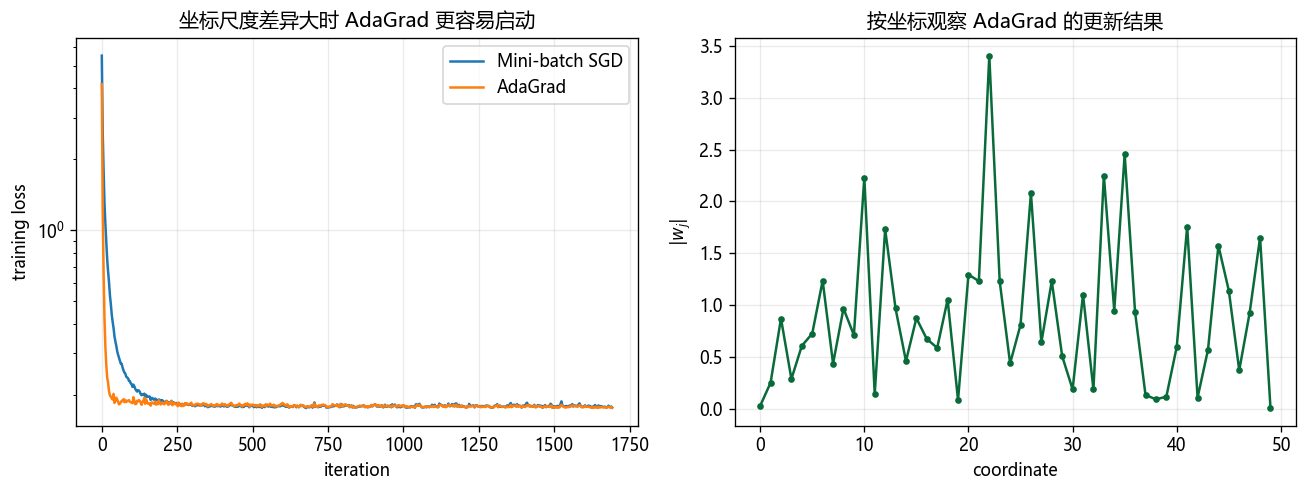

,method,iterations,runtime_sec,final_loss,grad_norm
1,AdaGrad,1692,0.668805,0.176228,0.034134
0,Mini-batch SGD,1692,0.573549,0.176934,0.048491


**观察：** 一个全局学习率难以兼顾所有坐标；AdaGrad 通过历史平方梯度为每个坐标形成不同有效步长。

,feature_count,mean_frequency,mean_effective_lr
group,,,
低频,31,94.967742,4.533216
中低频,29,196.551724,3.092202
中高频,30,411.266667,2.031716
高频,30,1167.266667,1.241493


图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_adagrad_sparse_feature_lr.png


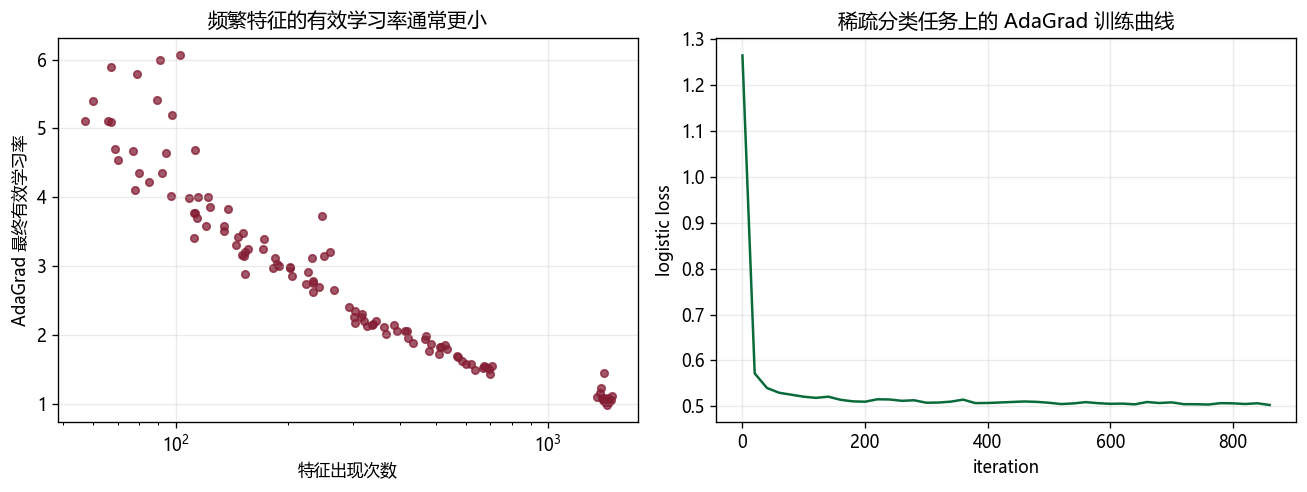

**观察：** 高频特征累积的平方梯度更大，因此 AdaGrad 给它们更小的有效学习率；低频特征则保留较大的更新机会。

In [9]:
X3, y3, _ = make_linear_data(n=9000, d=50, noise=0.6, condition=120, seed=8)
L3 = lipschitz_constant(X3)
adagrad_configs = [
    ("Mini-batch SGD", dict(method="sgd", lr=0.35 / L3, batch_size=64)),
    ("AdaGrad", dict(method="adagrad", lr=0.55, batch_size=64)),
]

adagrad_scale_results = {}
for name, kwargs in adagrad_configs:
    res = train_least_squares(X3, y3, epochs=12, schedule="constant", seed=9, record_every=3, **kwargs)
    adagrad_scale_results[name] = res
    add_summary("实验7", name, res["iterations"], res["runtime"], res["final_loss"], "尺度差异下的 AdaGrad")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, res in adagrad_scale_results.items():
    xs = np.linspace(0, res["iterations"], len(res["losses"]))
    axes[0].plot(xs, res["losses"], label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("training loss")
axes[0].set_title("坐标尺度差异大时 AdaGrad 更容易启动")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

final_abs_w = np.abs(adagrad_scale_results["AdaGrad"]["w"])
axes[1].plot(final_abs_w, marker="o", ms=3, color=DEEP_GREEN)
axes[1].set_xlabel("coordinate")
axes[1].set_ylabel(r"$|w_j|$")
axes[1].set_title("按坐标观察 AdaGrad 的更新结果")
axes[1].grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(PICS / "sgd_adagrad_coordinate_scale.png")
show_saved(PICS / "sgd_adagrad_coordinate_scale.png")
plt.show()

adagrad_scale_df = pd.DataFrame([
    {"method": name, "iterations": res["iterations"], "runtime_sec": res["runtime"], "final_loss": res["final_loss"], "grad_norm": res["grad_norms"][-1]}
    for name, res in adagrad_scale_results.items()
]).sort_values("final_loss")
display(adagrad_scale_df)
show_note("**观察：** 一个全局学习率难以兼顾所有坐标；AdaGrad 通过历史平方梯度为每个坐标形成不同有效步长。")


def make_sparse_logistic_data(n=7000, d=120, active_per_sample=8, seed=0):
    gen = np.random.default_rng(seed)
    probs = np.r_[np.repeat(0.025, 20), np.geomspace(0.012, 0.001, d - 20)]
    probs = probs / probs.sum()
    X = np.zeros((n, d))
    for i in range(n):
        idx = gen.choice(d, size=active_per_sample, replace=False, p=probs)
        X[i, idx] = gen.normal(loc=1.0, scale=0.2, size=active_per_sample)
    w_true = np.zeros(d)
    important = np.r_[np.arange(5), np.arange(60, 68), np.arange(100, 108)]
    w_true[important] = gen.normal(0, 1.8, size=len(important))
    logits = X @ w_true
    y = gen.binomial(1, sigmoid(logits))
    return X, y, w_true, X.astype(bool).sum(axis=0)


def logistic_loss(X, y, w):
    z = X @ w
    return np.mean(np.logaddexp(0, z) - y * z)


def logistic_grad(X, y, w, idx):
    Xb = X[idx]
    yb = y[idx]
    return Xb.T @ (sigmoid(Xb @ w) - yb) / len(idx)


Xs, ys, ws_true, frequency = make_sparse_logistic_data(seed=11)
w = np.zeros(Xs.shape[1])
accum = np.zeros_like(w)
base_alpha = 0.8
eps = 1e-8
loss_sparse = []
gen = np.random.default_rng(12)
step = 0
for epoch in range(8):
    for idx in iterate_minibatches(len(ys), 64, gen):
        g = logistic_grad(Xs, ys, w, idx)
        accum += g * g
        effective_lr = base_alpha / (np.sqrt(accum) + eps)
        w -= effective_lr * g
        if step % 20 == 0:
            loss_sparse.append(logistic_loss(Xs, ys, w))
        step += 1

freq_group = pd.qcut(frequency + 1e-9, q=4, labels=["低频", "中低频", "中高频", "高频"])
lr_by_group = pd.DataFrame({"frequency": frequency, "group": freq_group, "effective_lr": effective_lr})
sparse_lr_df = lr_by_group.groupby("group", observed=True).agg(feature_count=("frequency", "size"), mean_frequency=("frequency", "mean"), mean_effective_lr=("effective_lr", "mean"))
display(sparse_lr_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(frequency, effective_lr, s=20, alpha=0.75, color=SHANSHU)
axes[0].set_xscale("log")
axes[0].set_xlabel("特征出现次数")
axes[0].set_ylabel("AdaGrad 最终有效学习率")
axes[0].set_title("频繁特征的有效学习率通常更小")
axes[0].grid(True, alpha=0.25)
axes[1].plot(np.arange(len(loss_sparse)) * 20, loss_sparse, color=DEEP_GREEN)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("logistic loss")
axes[1].set_title("稀疏分类任务上的 AdaGrad 训练曲线")
axes[1].grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(PICS / "sgd_adagrad_sparse_feature_lr.png")
show_saved(PICS / "sgd_adagrad_sparse_feature_lr.png")
plt.show()
show_note("**观察：** 高频特征累积的平方梯度更大，因此 AdaGrad 给它们更小的有效学习率；低频特征则保留较大的更新机会。")
add_summary("实验7", "AdaGrad sparse logistic", step, 0.0, logistic_loss(Xs, ys, w), "稀疏特征有效学习率")

## 实验 8：RMSProp 与 AdaGrad 长时间训练时的有效步长差异

对应课件“RMSProp：只看近期梯度尺度”和“RMSProp 和 AdaGrad 的差别”。AdaGrad 使用全部历史平方梯度累加，$r_k$ 只增不减；RMSProp 使用指数移动平均

$$
r_k=\rho r_{k-1}+(1-\rho)(g_k\odot g_k).
$$

任务：构造一段“前期梯度大、后期梯度小”的序列，比较两种方法的有效步长。重点不是优化某个真实模型，而是看清楚为什么 RMSProp 不会像 AdaGrad 那样让有效步长持续缩到很小。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_rmsprop_adagrad_effective_lr.png


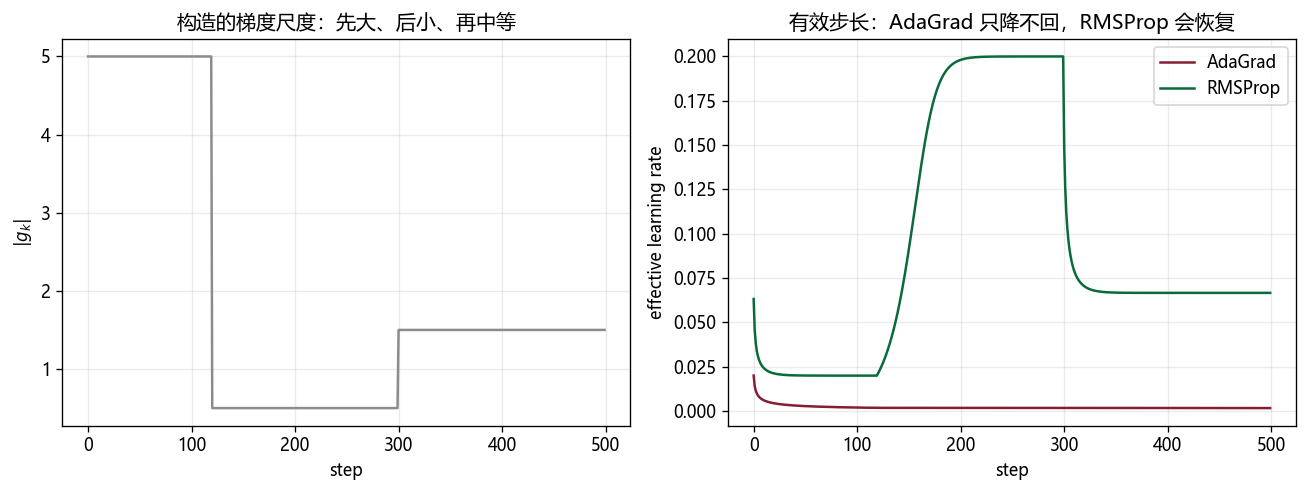

,method,effective_lr_after_large_grad,effective_lr_after_small_grad,final_effective_lr
0,AdaGrad,0.001826,0.001812,0.001692
1,RMSProp,0.020000,0.200000,0.066667


**观察：** AdaGrad 的历史平方和不会减少，所以早期大梯度会长期压低步长；RMSProp 遗忘旧梯度，更能适应后期尺度变化。

In [10]:
steps = 500
alpha = 0.1
rho = 0.9
grad_sequence = np.r_[np.full(120, 5.0), np.full(180, 0.5), np.full(200, 1.5)]
adagrad_r = 0.0
rmsprop_r = 0.0
adagrad_lr = []
rmsprop_lr = []
for g in grad_sequence:
    adagrad_r += g * g
    rmsprop_r = rho * rmsprop_r + (1 - rho) * g * g
    adagrad_lr.append(alpha / (np.sqrt(adagrad_r) + 1e-8))
    rmsprop_lr.append(alpha / (np.sqrt(rmsprop_r) + 1e-8))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(grad_sequence, color=HALF_GRAY)
axes[0].set_title("构造的梯度尺度：先大、后小、再中等")
axes[0].set_xlabel("step")
axes[0].set_ylabel(r"$|g_k|$")
axes[0].grid(True, alpha=0.25)
axes[1].plot(adagrad_lr, label="AdaGrad", color=SHANSHU)
axes[1].plot(rmsprop_lr, label="RMSProp", color=DEEP_GREEN)
axes[1].set_title("有效步长：AdaGrad 只降不回，RMSProp 会恢复")
axes[1].set_xlabel("step")
axes[1].set_ylabel("effective learning rate")
axes[1].grid(True, alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig.savefig(PICS / "sgd_rmsprop_adagrad_effective_lr.png")
show_saved(PICS / "sgd_rmsprop_adagrad_effective_lr.png")
plt.show()

rms_adagrad_df = pd.DataFrame({
    "method": ["AdaGrad", "RMSProp"],
    "effective_lr_after_large_grad": [adagrad_lr[119], rmsprop_lr[119]],
    "effective_lr_after_small_grad": [adagrad_lr[299], rmsprop_lr[299]],
    "final_effective_lr": [adagrad_lr[-1], rmsprop_lr[-1]],
})
display(rms_adagrad_df)
show_note("**观察：** AdaGrad 的历史平方和不会减少，所以早期大梯度会长期压低步长；RMSProp 遗忘旧梯度，更能适应后期尺度变化。")
add_summary("实验8", "AdaGrad vs RMSProp", steps, 0.0, float(rms_adagrad_df["final_effective_lr"].max()), "长时间训练有效步长")

## 实验 9：Adam 的一阶矩、二阶矩、偏差修正与坐标级有效步长

对应课件“Adam：动量 + 自适应步长”“偏差修正为什么出现”和“坐标级小例子”。Adam 同时维护

$$
m_k=\beta_1m_{k-1}+(1-\beta_1)g_k,
\qquad
v_k=\beta_2v_{k-1}+(1-\beta_2)(g_k\odot g_k).
$$

由于 $m_0=v_0=0$，训练初期需要偏差修正：

$$
\hat m_k=\frac{m_k}{1-\beta_1^k},\qquad
\hat v_k=\frac{v_k}{1-\beta_2^k}.
$$

任务：用两个坐标的梯度序列观察 Adam 如何同时平滑方向、估计尺度，并形成坐标级有效步长。

,step,g1,g2,m1_hat,m2_hat,sqrt_v1_hat,sqrt_v2_hat,update1,update2,effective_lr1,effective_lr2
0,1,0.600,3.0,0.600000,3.000000,0.600000,3.000000,0.020000,0.020000,0.033333,0.006667
1,2,0.575,-2.0,0.586842,0.368421,0.587570,2.547045,0.019975,0.002893,0.034740,0.001446
2,3,0.550,2.4,0.573247,1.118081,0.575195,2.498503,0.019932,0.008950,0.036241,0.003729
3,4,0.525,-1.5,0.559218,0.356790,0.562880,2.286764,0.019870,0.003120,0.037847,0.002080
4,5,0.500,2.0,0.544757,0.758052,0.550634,2.231248,0.019787,0.006795,0.039573,0.003397
5,6,0.475,-1.0,0.529870,0.382848,0.538462,2.073311,0.019681,0.003693,0.041433,0.003693
6,7,0.450,1.4,0.514560,0.577816,0.526375,1.988560,0.019551,0.005811,0.043447,0.004151
7,8,0.425,-0.8,0.498835,0.335895,0.514379,1.877593,0.019396,0.003578,0.045637,0.004472


图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_adam_moments_effective_lr.png


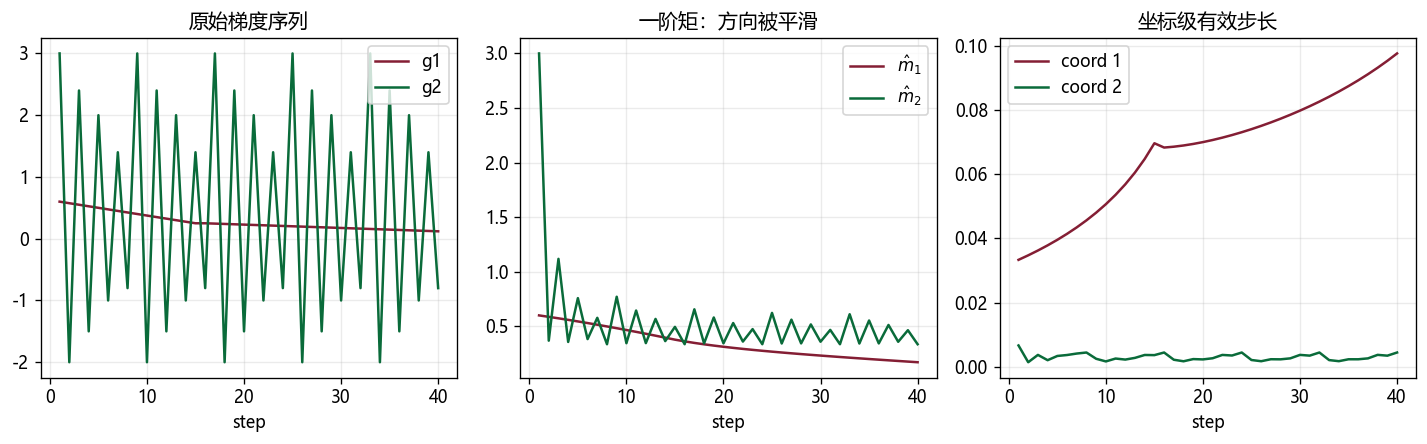

,beta,raw_at_step_1,corrected_at_step_1,raw_at_step_7,corrected_at_step_7
0,0.90,0.10,1.0,0.521703,1.0
1,0.99,0.01,1.0,0.067935,1.0


**观察：** Adam 的一阶矩让方向更平滑，二阶矩让大尺度坐标的有效步长变小；偏差修正把训练初期被 0 拉小的移动平均校正回来。

In [11]:
def adam_trace(gradients, alpha=0.02, beta1=0.9, beta2=0.99, eps=1e-8):
    gradients = np.asarray(gradients, dtype=float)
    m = np.zeros(gradients.shape[1])
    v = np.zeros(gradients.shape[1])
    rows = []
    for t, g in enumerate(gradients, start=1):
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        step = alpha * m_hat / (np.sqrt(v_hat) + eps)
        rows.append({
            "step": t,
            "g1": g[0], "g2": g[1],
            "m1_hat": m_hat[0], "m2_hat": m_hat[1],
            "sqrt_v1_hat": np.sqrt(v_hat[0]), "sqrt_v2_hat": np.sqrt(v_hat[1]),
            "update1": step[0], "update2": step[1],
            "effective_lr1": abs(step[0] / g[0]) if abs(g[0]) > 1e-12 else np.nan,
            "effective_lr2": abs(step[1] / g[1]) if abs(g[1]) > 1e-12 else np.nan,
        })
    return pd.DataFrame(rows)


# 第 1 个坐标方向较稳定；第 2 个坐标梯度尺度大且方向更抖。
gradients = np.column_stack([
    np.r_[np.linspace(0.6, 0.25, 15), np.linspace(0.25, 0.12, 25)],
    np.array([3.0, -2.0, 2.4, -1.5, 2.0, -1.0, 1.4, -0.8] * 5),
])
adam_df = adam_trace(gradients)
display(adam_df.head(8))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].plot(adam_df["step"], adam_df["g1"], label="g1", color=SHANSHU)
axes[0].plot(adam_df["step"], adam_df["g2"], label="g2", color=DEEP_GREEN)
axes[0].set_title("原始梯度序列")
axes[0].set_xlabel("step")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(adam_df["step"], adam_df["m1_hat"], label=r"$\hat m_1$", color=SHANSHU)
axes[1].plot(adam_df["step"], adam_df["m2_hat"], label=r"$\hat m_2$", color=DEEP_GREEN)
axes[1].set_title("一阶矩：方向被平滑")
axes[1].set_xlabel("step")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

axes[2].plot(adam_df["step"], adam_df["effective_lr1"], label="coord 1", color=SHANSHU)
axes[2].plot(adam_df["step"], adam_df["effective_lr2"], label="coord 2", color=DEEP_GREEN)
axes[2].set_title("坐标级有效步长")
axes[2].set_xlabel("step")
axes[2].grid(True, alpha=0.25)
axes[2].legend()
fig.tight_layout()
fig.savefig(PICS / "sgd_adam_moments_effective_lr.png")
show_saved(PICS / "sgd_adam_moments_effective_lr.png")
plt.show()

bias_rows = []
for beta in [0.9, 0.99]:
    raw = 0.0
    corrected = []
    uncorrected = []
    for t in range(1, 8):
        raw = beta * raw + (1 - beta) * 1.0
        uncorrected.append(raw)
        corrected.append(raw / (1 - beta ** t))
    bias_rows.append({"beta": beta, "raw_at_step_1": uncorrected[0], "corrected_at_step_1": corrected[0], "raw_at_step_7": uncorrected[-1], "corrected_at_step_7": corrected[-1]})
display(pd.DataFrame(bias_rows))
show_note("**观察：** Adam 的一阶矩让方向更平滑，二阶矩让大尺度坐标的有效步长变小；偏差修正把训练初期被 0 拉小的移动平均校正回来。")
add_summary("实验9", "Adam moments", len(adam_df), 0.0, float(adam_df[["effective_lr1", "effective_lr2"]].mean().mean()), "一阶矩、二阶矩与偏差修正")

## 实验 10：AdamW/权重衰减与优化器选择思考题

对应课件“Adam 不是万能的”“AdamW：深度学习中的常见变体”“优化器选择”和“常见误区”。AdamW 的核心是把权重衰减从自适应梯度更新中解耦：

$$
w^{k+1}:=w^k-\alpha\frac{\hat m_k}{\sqrt{\hat v_k}+\epsilon}-\alpha\lambda w^k.
$$

任务 A：比较 Adam 中把 $\lambda w$ 加进梯度的做法与 AdamW 的解耦权重衰减。任务 B：根据实验现象完成最后的优化器选择小题。

图片已保存: D:\课程\课件 优化理论与算法2025\优化理论与算法第八章\优化理论与算法第八章\pics\sgd_adamw_weight_decay.png


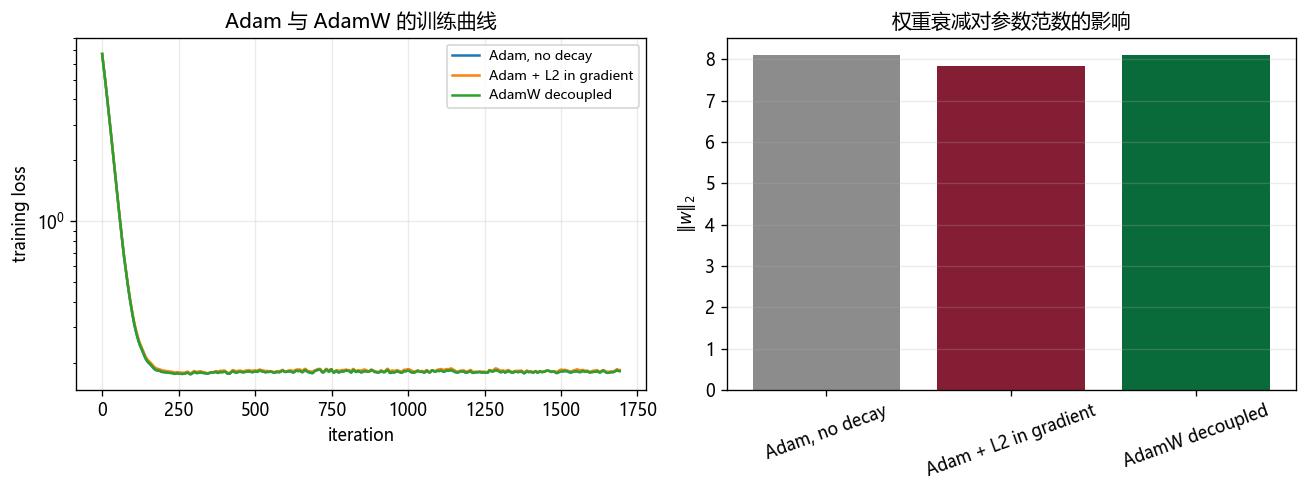

,method,final_loss,weight_norm,grad_norm
2,AdamW decoupled,0.182610,8.102992,0.077892
0,"Adam, no decay",0.182628,8.107735,0.077987
1,Adam + L2 in gradient,0.184759,7.840643,0.078465


,场景,优先尝试,理由
0,大规模有限和目标，单步全梯度太贵,SGD / Mini-batch SGD,用低成本随机方向换取更多更新机会
1,mini-batch 轨迹 zig-zag 明显,SGD + Momentum / Nesterov,平滑历史方向，减少来回摆动
2,稀疏特征或长尾 embedding,AdaGrad / Adam / AdamW,坐标级状态能处理更新频率差异
3,长时间训练中 AdaGrad 后期步长过小,RMSProp / Adam,近期平方梯度平均会遗忘很久以前的尺度
4,深度网络初期想快速得到可用模型,Adam / AdamW,方向平滑与坐标自适应结合，启动通常较快
5,追求最终泛化表现,学习率衰减、AdamW、SGD + Momentum,训练 loss 快不等于泛化最好，需要验证集判断


**思考题：** 如果 Adam 初期 loss 下降最快，是否就一定应该全程使用 Adam？请结合验证集、权重衰减和学习率衰减回答。

In [12]:
adamw_configs = [
    ("Adam, no decay", dict(method="adam", lr=0.025, beta1=0.9, beta2=0.99, batch_size=64, weight_decay=0.0, decoupled_weight_decay=False)),
    ("Adam + L2 in gradient", dict(method="adam", lr=0.025, beta1=0.9, beta2=0.99, batch_size=64, weight_decay=2e-3, decoupled_weight_decay=False)),
    ("AdamW decoupled", dict(method="adam", lr=0.025, beta1=0.9, beta2=0.99, batch_size=64, weight_decay=2e-3, decoupled_weight_decay=True)),
]

adamw_results = {}
for name, kwargs in adamw_configs:
    res = train_least_squares(X3, y3, epochs=12, schedule="constant", seed=13, record_every=3, **kwargs)
    adamw_results[name] = res
    add_summary("实验10", name, res["iterations"], res["runtime"], res["final_loss"], "AdamW 与权重衰减")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, res in adamw_results.items():
    xs = np.linspace(0, res["iterations"], len(res["losses"]))
    axes[0].plot(xs, res["losses"], label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("training loss")
axes[0].set_title("Adam 与 AdamW 的训练曲线")
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=8)

norms = [np.linalg.norm(res["w"]) for res in adamw_results.values()]
axes[1].bar(list(adamw_results.keys()), norms, color=[HALF_GRAY, SHANSHU, DEEP_GREEN])
axes[1].set_ylabel(r"$\|w\|_2$")
axes[1].set_title("权重衰减对参数范数的影响")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(PICS / "sgd_adamw_weight_decay.png")
show_saved(PICS / "sgd_adamw_weight_decay.png")
plt.show()

adamw_df = pd.DataFrame([
    {"method": name, "final_loss": res["final_loss"], "weight_norm": np.linalg.norm(res["w"]), "grad_norm": res["grad_norms"][-1]}
    for name, res in adamw_results.items()
]).sort_values("final_loss")
display(adamw_df)

choice_quiz = pd.DataFrame([
    {"场景": "大规模有限和目标，单步全梯度太贵", "优先尝试": "SGD / Mini-batch SGD", "理由": "用低成本随机方向换取更多更新机会"},
    {"场景": "mini-batch 轨迹 zig-zag 明显", "优先尝试": "SGD + Momentum / Nesterov", "理由": "平滑历史方向，减少来回摆动"},
    {"场景": "稀疏特征或长尾 embedding", "优先尝试": "AdaGrad / Adam / AdamW", "理由": "坐标级状态能处理更新频率差异"},
    {"场景": "长时间训练中 AdaGrad 后期步长过小", "优先尝试": "RMSProp / Adam", "理由": "近期平方梯度平均会遗忘很久以前的尺度"},
    {"场景": "深度网络初期想快速得到可用模型", "优先尝试": "Adam / AdamW", "理由": "方向平滑与坐标自适应结合，启动通常较快"},
    {"场景": "追求最终泛化表现", "优先尝试": "学习率衰减、AdamW、SGD + Momentum", "理由": "训练 loss 快不等于泛化最好，需要验证集判断"},
])
display(choice_quiz)
show_note("**思考题：** 如果 Adam 初期 loss 下降最快，是否就一定应该全程使用 Adam？请结合验证集、权重衰减和学习率衰减回答。")

## 实验总结：把实验现象对应回课件

运行完所有实验后，可以用下面的表格快速回顾每个实验对应的新版课件主线。最后请把每个场景对应到一个优化器选择，并写出“不选另一个方法”的理由。

In [13]:
summary_df = pd.DataFrame(summaries)
display(summary_df)
show_note("**使用建议：** 课堂演示时可以逐个实验运行；每个实验的图会直接显示，也会同步保存到 `pics` 目录。")

experiment_map = pd.DataFrame([
    {"课件主线": "有限和目标；GD / SGD / Mini-batch", "实验": "实验1", "学生要回答": "单步代价和梯度噪声如何权衡？"},
    {"课件主线": "iteration、batch、epoch、batch size", "实验": "实验2", "学生要回答": "batch 越大是否一定单位时间更快？"},
    {"课件主线": "学习率调度与 SGD 稳定性", "实验": "实验3", "学生要回答": "为什么后期常要降低学习率？"},
    {"课件主线": "推荐、广告、LLM embedding 等应用", "实验": "实验4", "学生要回答": "稀疏参数为何适合随机/小批量更新？"},
    {"课件主线": "Momentum 平滑方向，减少 zig-zag", "实验": "实验5", "学生要回答": "哪些方向被保留，哪些摆动被抵消？"},
    {"课件主线": "Nesterov 先看前方再修正", "实验": "实验6", "学生要回答": "lookahead 梯度如何帮助提前纠偏？"},
    {"课件主线": "AdaGrad 历史平方梯度；稀疏特征", "实验": "实验7", "学生要回答": "高频和低频坐标的有效步长有何不同？"},
    {"课件主线": "RMSProp 近期平方梯度；区别于 AdaGrad", "实验": "实验8", "学生要回答": "为什么 RMSProp 适合长时间训练？"},
    {"课件主线": "Adam 一阶矩、二阶矩、偏差修正", "实验": "实验9", "学生要回答": "Adam 如何同时平滑方向和缩放坐标？"},
    {"课件主线": "AdamW、优化器选择、常见误区", "实验": "实验10", "学生要回答": "Adam 初期快是否代表全程最优？"},
])
display(experiment_map)

optimizer_guide = pd.DataFrame([
    {"场景": "大规模有限和目标，单步全梯度太贵", "常见选择": "SGD、Mini-batch SGD", "实验对应": "实验1-2"},
    {"场景": "训练后期围绕低点抖动", "常见选择": "学习率衰减、cosine、step decay", "实验对应": "实验3"},
    {"场景": "推荐/广告/embedding 中 ID 更新很稀疏", "常见选择": "Mini-batch + AdaGrad/Adam/AdamW", "实验对应": "实验4、实验7、实验9"},
    {"场景": "loss 曲线抖动、zig-zag 明显", "常见选择": "SGD + Momentum / Nesterov", "实验对应": "实验5-6"},
    {"场景": "坐标尺度差异大或稀疏特征", "常见选择": "AdaGrad、Adam", "实验对应": "实验7、实验9"},
    {"场景": "长时间训练中 AdaGrad 后期步长太小", "常见选择": "RMSProp、Adam", "实验对应": "实验8-9"},
    {"场景": "深度网络初期快速得到可用模型", "常见选择": "Adam 或 AdamW", "实验对应": "实验9-10"},
    {"场景": "追求最终泛化表现", "常见选择": "验证集调参、权重衰减、学习率衰减、SGD + Momentum", "实验对应": "实验3、实验10"},
])
display(optimizer_guide)

,experiment,method,iterations,runtime_sec,final_loss,note
0,实验1,GD/SGD/Mini-batch,900,0.001912,2.721877e-15,单步代价与梯度噪声比较
1,实验2,"SGD, batch=1",20000,1.043755,4.895915e-01,"batch=1, lr=0.104"
2,实验2,"Mini-batch, batch=32",2504,0.417725,2.672111e-01,"batch=32, lr=0.347"
3,实验2,"Mini-batch, batch=256",800,0.344979,2.548930e-01,"batch=256, lr=0.556"
4,实验2,GD/full batch,35,0.139647,2.579566e-01,"batch=10000, lr=0.694"
5,实验3,constant,2355,0.971753,2.727829e-01,学习率调度
6,实验3,sqrt_decay,2355,0.884687,2.494255e-01,学习率调度
7,实验3,step_decay,2355,0.883059,2.484680e-01,学习率调度
8,实验3,cosine_warmup,2355,1.012534,2.485170e-01,学习率调度
9,实验4,sparse recommendation updates,160,0.023182,6.824376e-01,应用案例：稀疏参数与 mini-batch


**使用建议：** 课堂演示时可以逐个实验运行；每个实验的图会直接显示，也会同步保存到 `pics` 目录。

,课件主线,实验,学生要回答
0,有限和目标；GD / SGD / Mini-batch,实验1,单步代价和梯度噪声如何权衡？
1,iteration、batch、epoch、batch size,实验2,batch 越大是否一定单位时间更快？
2,学习率调度与 SGD 稳定性,实验3,为什么后期常要降低学习率？
3,推荐、广告、LLM embedding 等应用,实验4,稀疏参数为何适合随机/小批量更新？
4,Momentum 平滑方向，减少 zig-zag,实验5,哪些方向被保留，哪些摆动被抵消？
5,Nesterov 先看前方再修正,实验6,lookahead 梯度如何帮助提前纠偏？
6,AdaGrad 历史平方梯度；稀疏特征,实验7,高频和低频坐标的有效步长有何不同？
7,RMSProp 近期平方梯度；区别于 AdaGrad,实验8,为什么 RMSProp 适合长时间训练？
8,Adam 一阶矩、二阶矩、偏差修正,实验9,Adam 如何同时平滑方向和缩放坐标？
9,AdamW、优化器选择、常见误区,实验10,Adam 初期快是否代表全程最优？


,场景,常见选择,实验对应
0,大规模有限和目标，单步全梯度太贵,SGD、Mini-batch SGD,实验1-2
1,训练后期围绕低点抖动,学习率衰减、cosine、step decay,实验3
2,推荐/广告/embedding 中 ID 更新很稀疏,Mini-batch + AdaGrad/Adam/AdamW,实验4、实验7、实验9
3,loss 曲线抖动、zig-zag 明显,SGD + Momentum / Nesterov,实验5-6
4,坐标尺度差异大或稀疏特征,AdaGrad、Adam,实验7、实验9
5,长时间训练中 AdaGrad 后期步长太小,RMSProp、Adam,实验8-9
6,深度网络初期快速得到可用模型,Adam 或 AdamW,实验9-10
7,追求最终泛化表现,验证集调参、权重衰减、学习率衰减、SGD + Momentum,实验3、实验10
